# Bacpipe Tutorial

This notebook walks through the main workflows of the `bacpipe` library — from inspecting configuration and loading audio, through generating embeddings with built-in and custom models, to running the full pipeline and benchmarking classifier performance.



Make sure to reset your config and settings files before running this notebook, 
as they may contain settings from previous runs that could prevent this notebook 
from finding the correct paths.
---

**Contents**
1. [Setup & Configuration](#1.-Setup-&-Configuration)
2. [Loading Audio Files](#2.-Loading-Audio-Files)
3. [Ground Truth Labels](#3.-Ground-Truth-Labels)
4. [End-to-End: bacpipe.play](#4.-End-to-End:-bacpipe.play)
5. [Full Pipeline - Single Model](#5.-Full-Pipeline---Single-Model)
6. [Full Pipeline - Multiple Models](#6.-Full-Pipeline---Multiple-Models)
7. [Generating Embeddings - Full Directory (Save to Disk)](#7.-Generating-Embeddings---Full-Directory-(Save-to-Disk))
8. [Generating Embeddings - Single File (In-Memory)](#8.-Generating-Embeddings---Single-File-(In-Memory))
9. [High-Level Workflow - generate_embeddings](#9.-High-Level-Workflow---generate_embeddings)
10. [Benchmarking Classifier Performance](#10.-Benchmarking-Classifier-Performance)

---
## 0. Imports & Working Directory

Set the working directory to the repo root and import the display utility.

In [1]:
# to run successfully the packages for jupyter notebook need to be installed:
# uv pip install ipykernel, ipython

import os
from pathlib import Path

# load the specific package
import bacpipe

%matplotlib inline

In [2]:
# get the path to the folder where the notebook is located
notebook_path = Path().resolve()

# get the name of the current notebook file
notebook_file = 'gui_bacpipe'

# get the directoy where the notebook is located
notebook_dir = notebook_path.name

# working directory 
wd_path = notebook_path.parent

# set the audio directory to the folder 
# audio files directory
bacpipe.config.audio_dir = str( wd_path / 'bacpipe_data' / notebook_file) 

# Change the value of the key main_results_dir in the namespace bacpipe.settings to change the directory 
# where the results of the tutorials are stored. By default, it is set to './bacpipe_results'.
bacpipe.settings.main_results_dir = str(wd_path / 'bacpipe_results')

bacpipe.settings.device = 'cuda' # choose 'cpu' or 'cuda' depending on your system configuration. 
bacpipe.config.dim_reduction_model = 'umap' # choose 'pca' or 'umap' depending on your preference.

MODELS_LIST = ['birdnet', "beats", "birdnet_v3" ] # list of models to run. Supported models are in bacpipe.supported_models

# # !WARNING! the following code deletes the folder where the results of this tutorial is stored to be sure to start with a clean folder. 
# # If you have important data in this folder, please comment it before running this code.
# folder_path = bacpipe.settings.main_results_dir
# if os.path.exists(folder_path):
#     # Prompt the user
#     user_input = input(f"Are you sure you want to delete '{folder_path}'? (y/n): ").lower().strip()

#     if user_input == 'y':
#         import shutilbacpipe.config.audio_dir
#         shutil.rmtree(folder_path) 
#         print(f"Folder {folder_path} deleted.")
#     else:
#         print("Operation cancelled.")

# else:
#     print(f"Folder {folder_path} not found.")

---
## 1. Setup & Configuration

Import `bacpipe` and inspect the current configuration and settings. You can also list all available API endpoints, supported models, and the embedding dimensions for each model.

In [3]:
import bacpipe

print('Config:')
display(bacpipe.config)

print('Settings:')
display(bacpipe.settings)

Config:


namespace(audio_dir='/media/haupert/data/mes_projets/_cesco-ia/session_20260908/tp_bacpipe/bacpipe_data/gui_bacpipe',
          overwrite=True,
          dashboard=True,
          models=['birdnet', 'perch_bird'],
          already_computed=False,
          dim_reduction_model='umap',
          evaluation_task=[])

Settings:


namespace(main_results_dir='/media/haupert/data/mes_projets/_cesco-ia/session_20260908/tp_bacpipe/bacpipe_results',
          embed_parent_dir='embeddings',
          dim_reduc_parent_dir='dim_reduced_embeddings',
          evaluations_dir='evaluations',
          model_base_path='bacpipe_model_checkpoints',
          device='cuda',
          global_batch_size=8,
          audio_suffixes=['.wav',
                          '.WAV',
                          '.aif',
                          '.mp3',
                          '.MP3',
                          '.flac',
                          '.ogg'],
          padding='wrap',
          avoid_pipelined_gpu_inference=False,
          nr_parallel_workers=False,
          rm_embedding_on_keyboard_interrupt=False,
          check_if_already_processed=True,
          check_if_already_dim_reduced=True,
          label_column='species',
          annotations_filename='annotations.csv',
          only_embed_annotations=False,
          min_annota

---
## 4. End-to-End: `bacpipe.play`

`bacpipe.play` is the highest-level entry point. It runs the complete pipeline —
embeddings, classification, dimensionality reduction, evaluation, and an
interactive dashboard — in a single call. Ideal for a first exploration of a new
dataset across multiple models.

`play` does not return anything: all intermediate outputs are saved to disk and
the dashboard is launched automatically (unless disabled in the `config.yaml`
file). The models to run are passed with the `models` keyword (or taken from
`bacpipe.config.models`).

If a webpage with the dashboard is not automatically opened within your default
internet browser (e.g. chrome), copy then paste the URL displayed in the output
in a new page of your browser (e.g. http://localhost:5006).

The next cells select the device on which the models should run.
`bacpipe.settings.device` can be set to `'cpu'` (always works) or `'cuda'`
(only if a compatible NVIDIA GPU is available). If you do not have a GPU, leave
the default `'cpu'` to avoid CUDA errors.


Checking if the selected models require a checkpoint, and if so, if the checkpoint already exists.

birdnet checkpoint exists.

beats checkpoint exists.

birdnet_v3 checkpoint exists.

Checking if the selected models require a checkpoint, and if so, if the checkpoint already exists.

birdnet checkpoint exists.




###### Generating embeddings using BIRDNET ######

Finding all generated embeddings: 117it [00:00, 182496.68it/s]
Found 117 embedding files.
finding audio files: 122it [00:00, 249368.95it/s]
Found 117 number of audio files.

### Embeddings already exist. Using embeddings in /media/haupert/data/mes_projets/_cesco-ia/session_20260908/tp_bacpipe/bacpipe_results/gui_bacpipe/embeddings/2026-09-14_14-54___birdnet-gui_bacpipe ###
Checking if the selected models require a checkpoint, and if so, if the checkpoint already exists.

birdnet checkpoint exists.




###### Generating embeddings using UMAP ######

2026-09-14 14:58:46.498309: I tensorflow/core/util/port.cc:153] oneDNN custom 

Launching server at http://localhost:5007


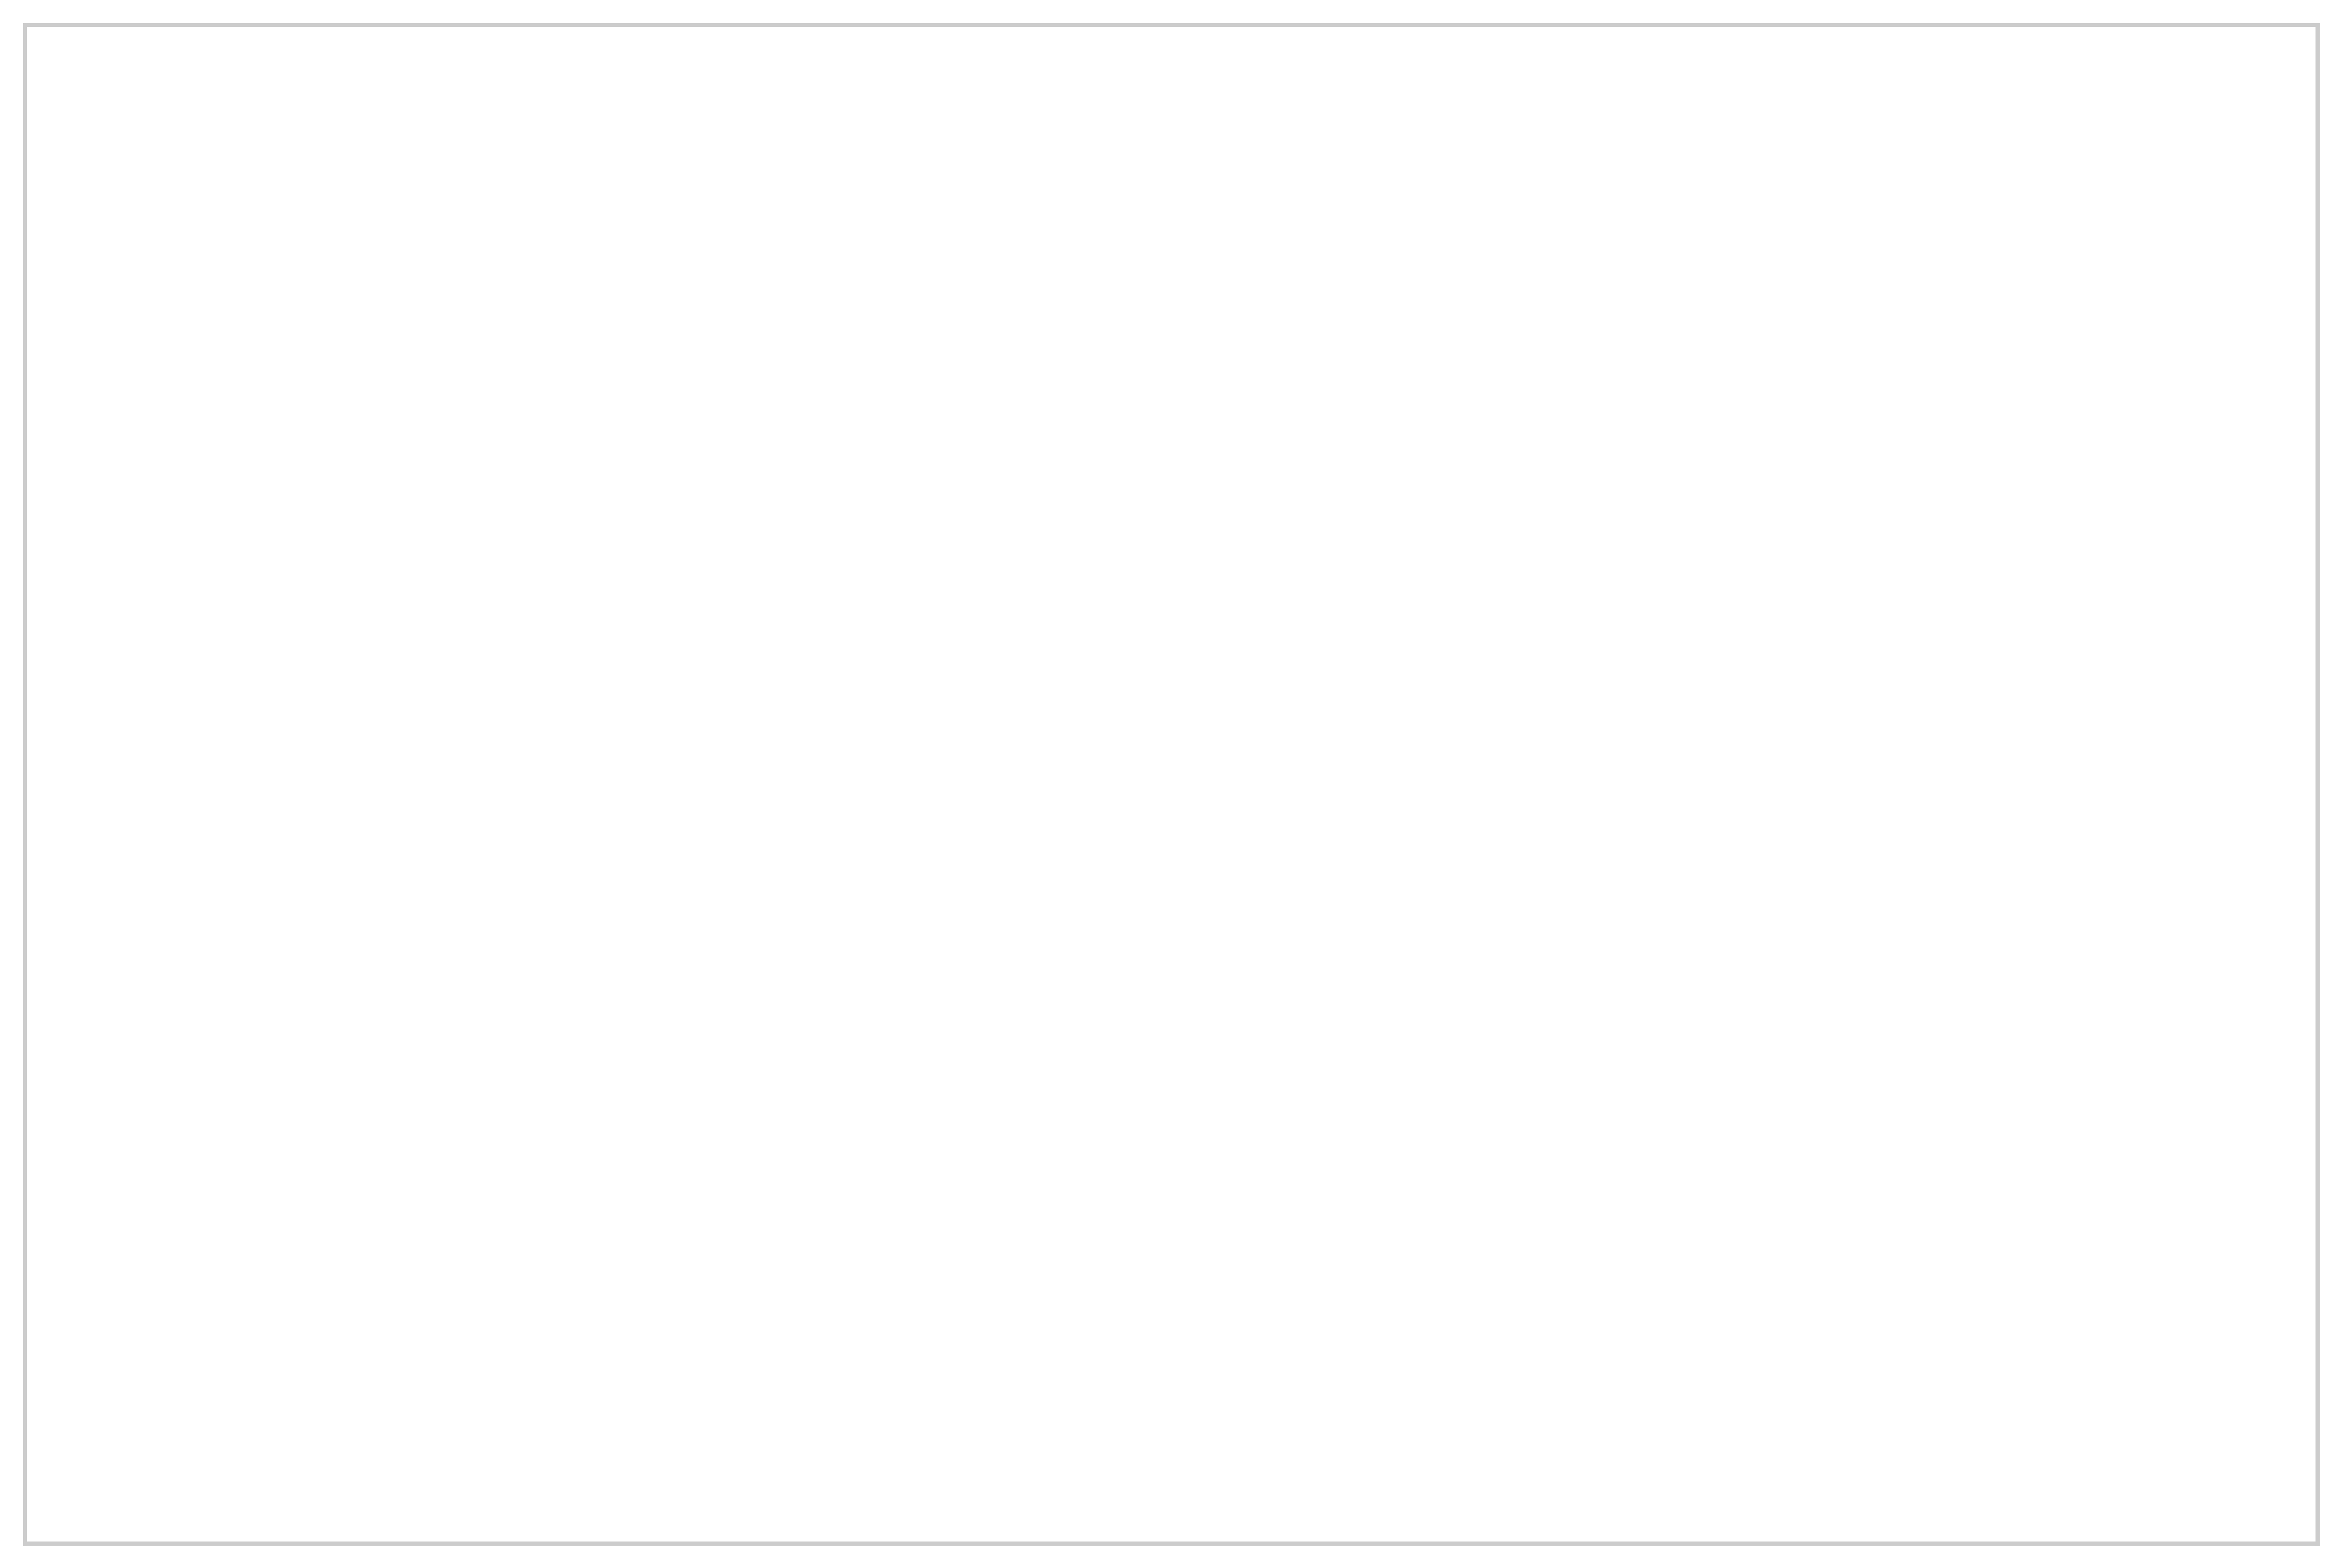

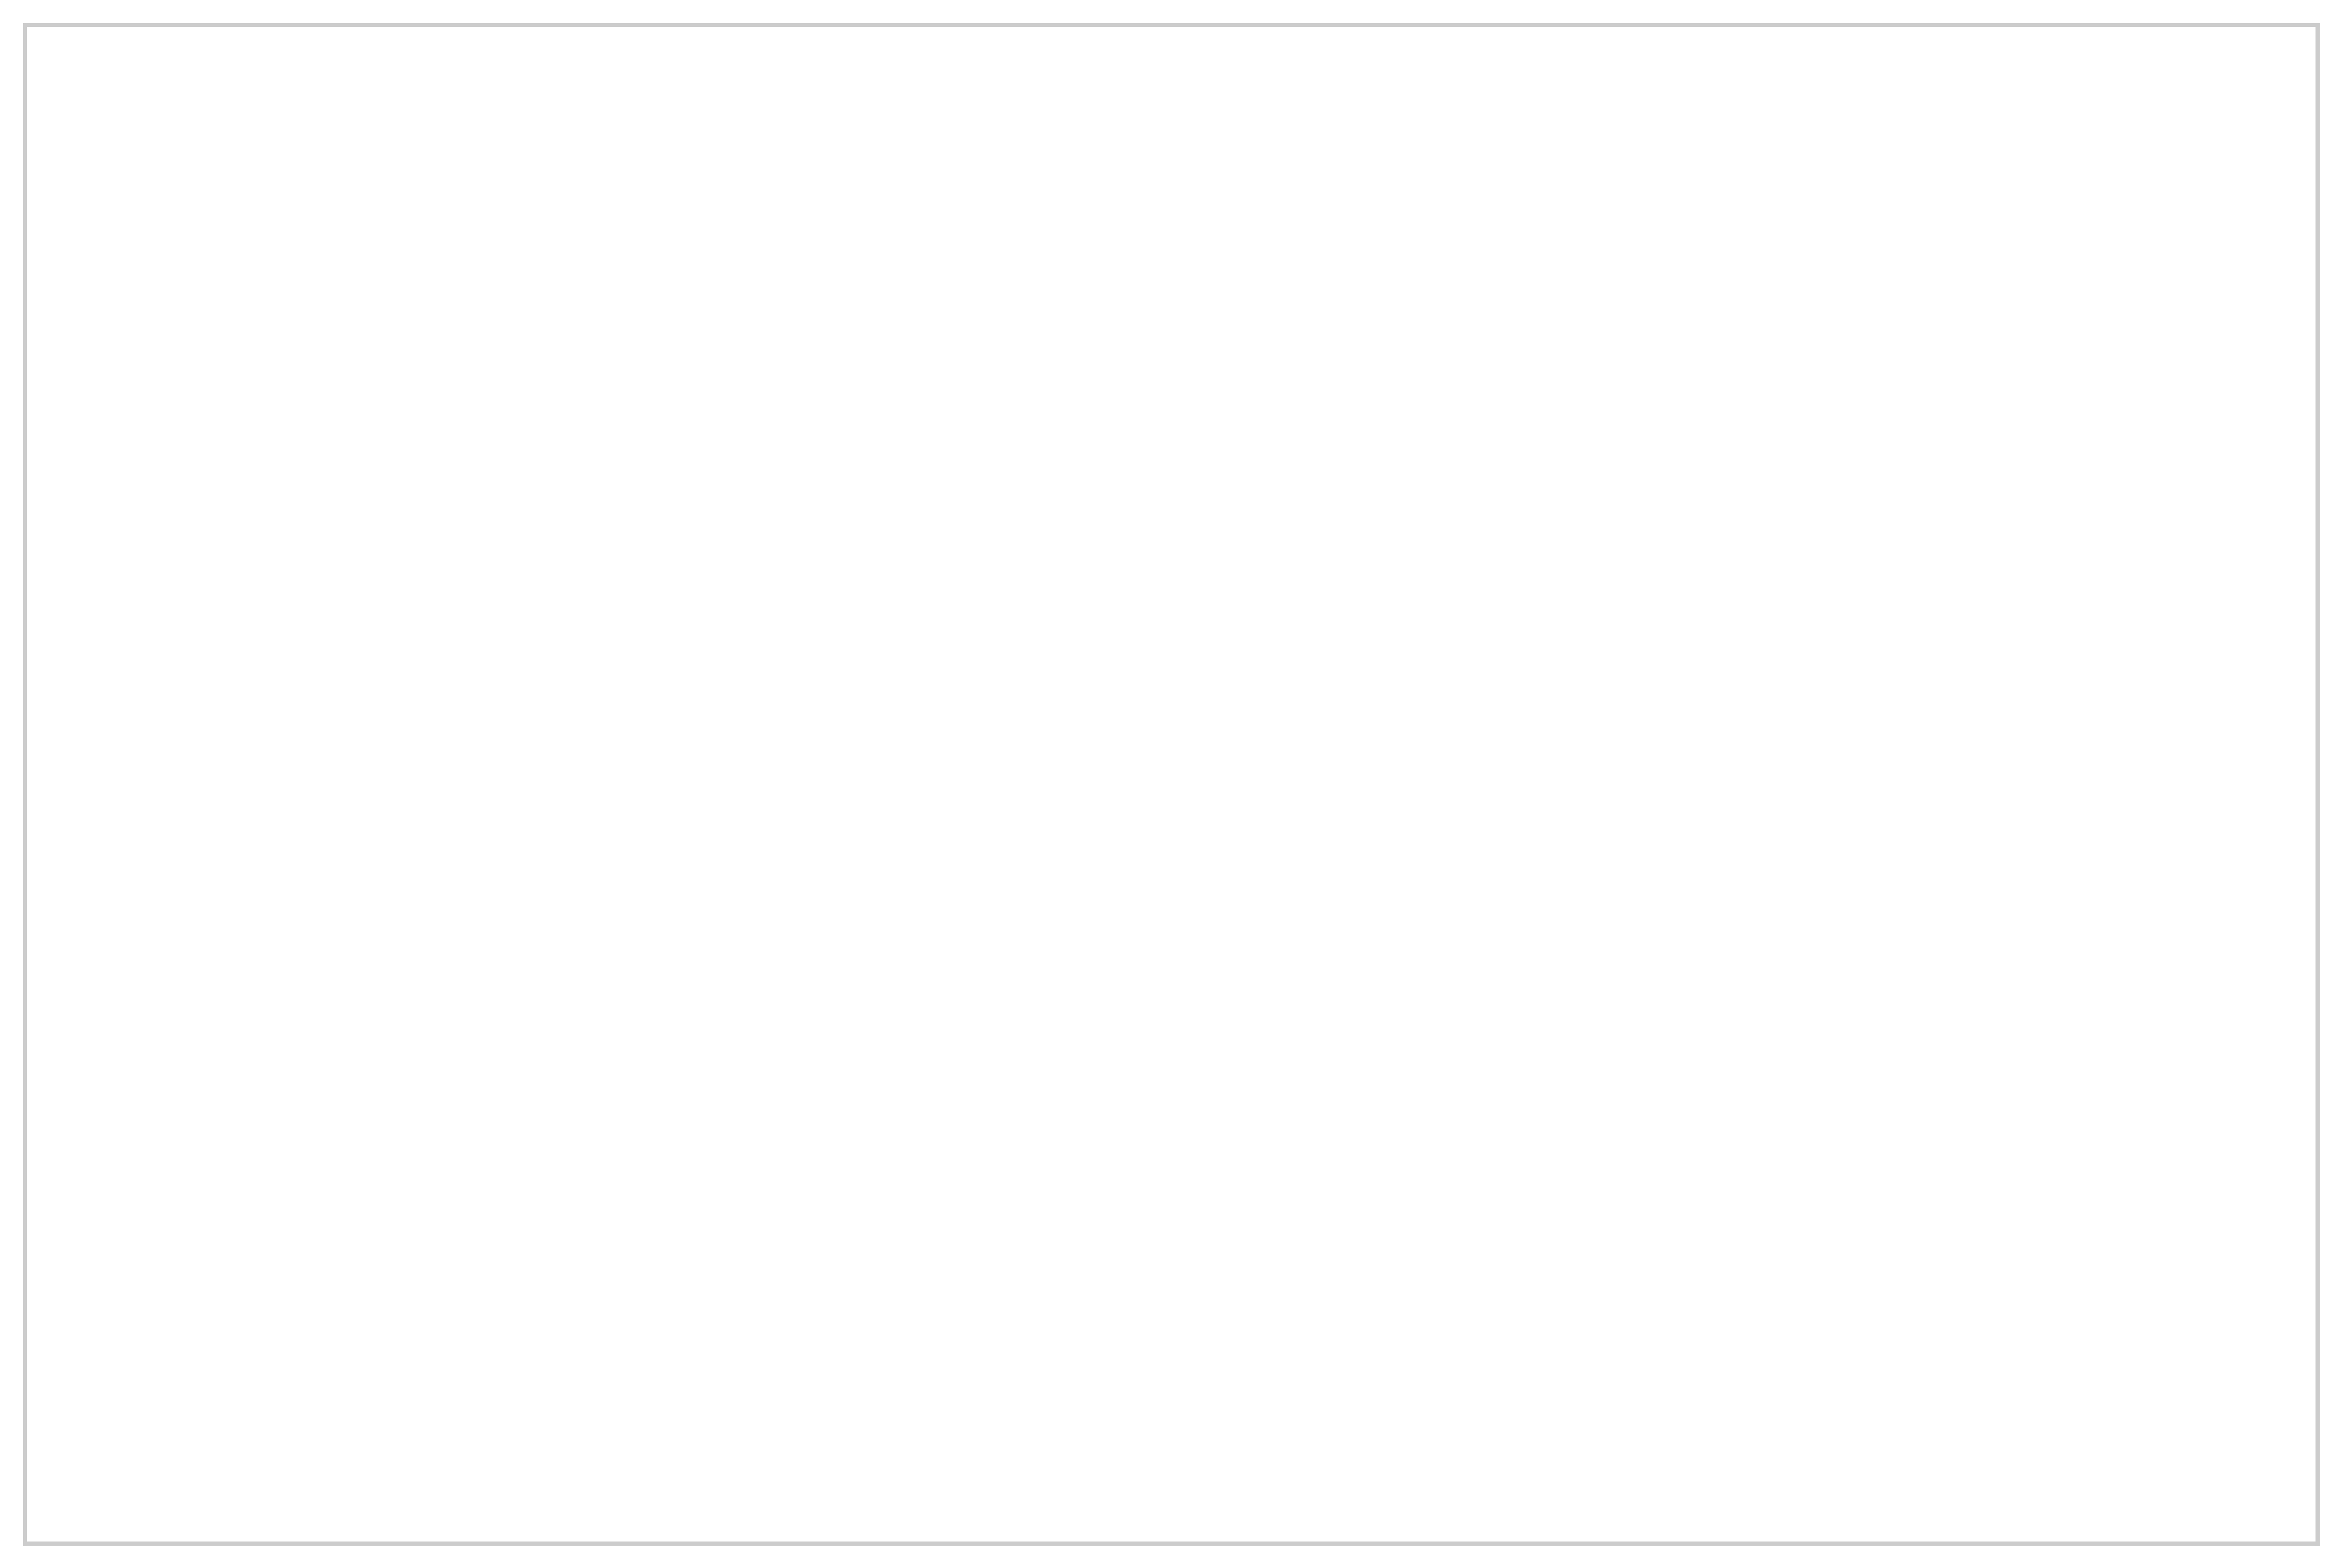

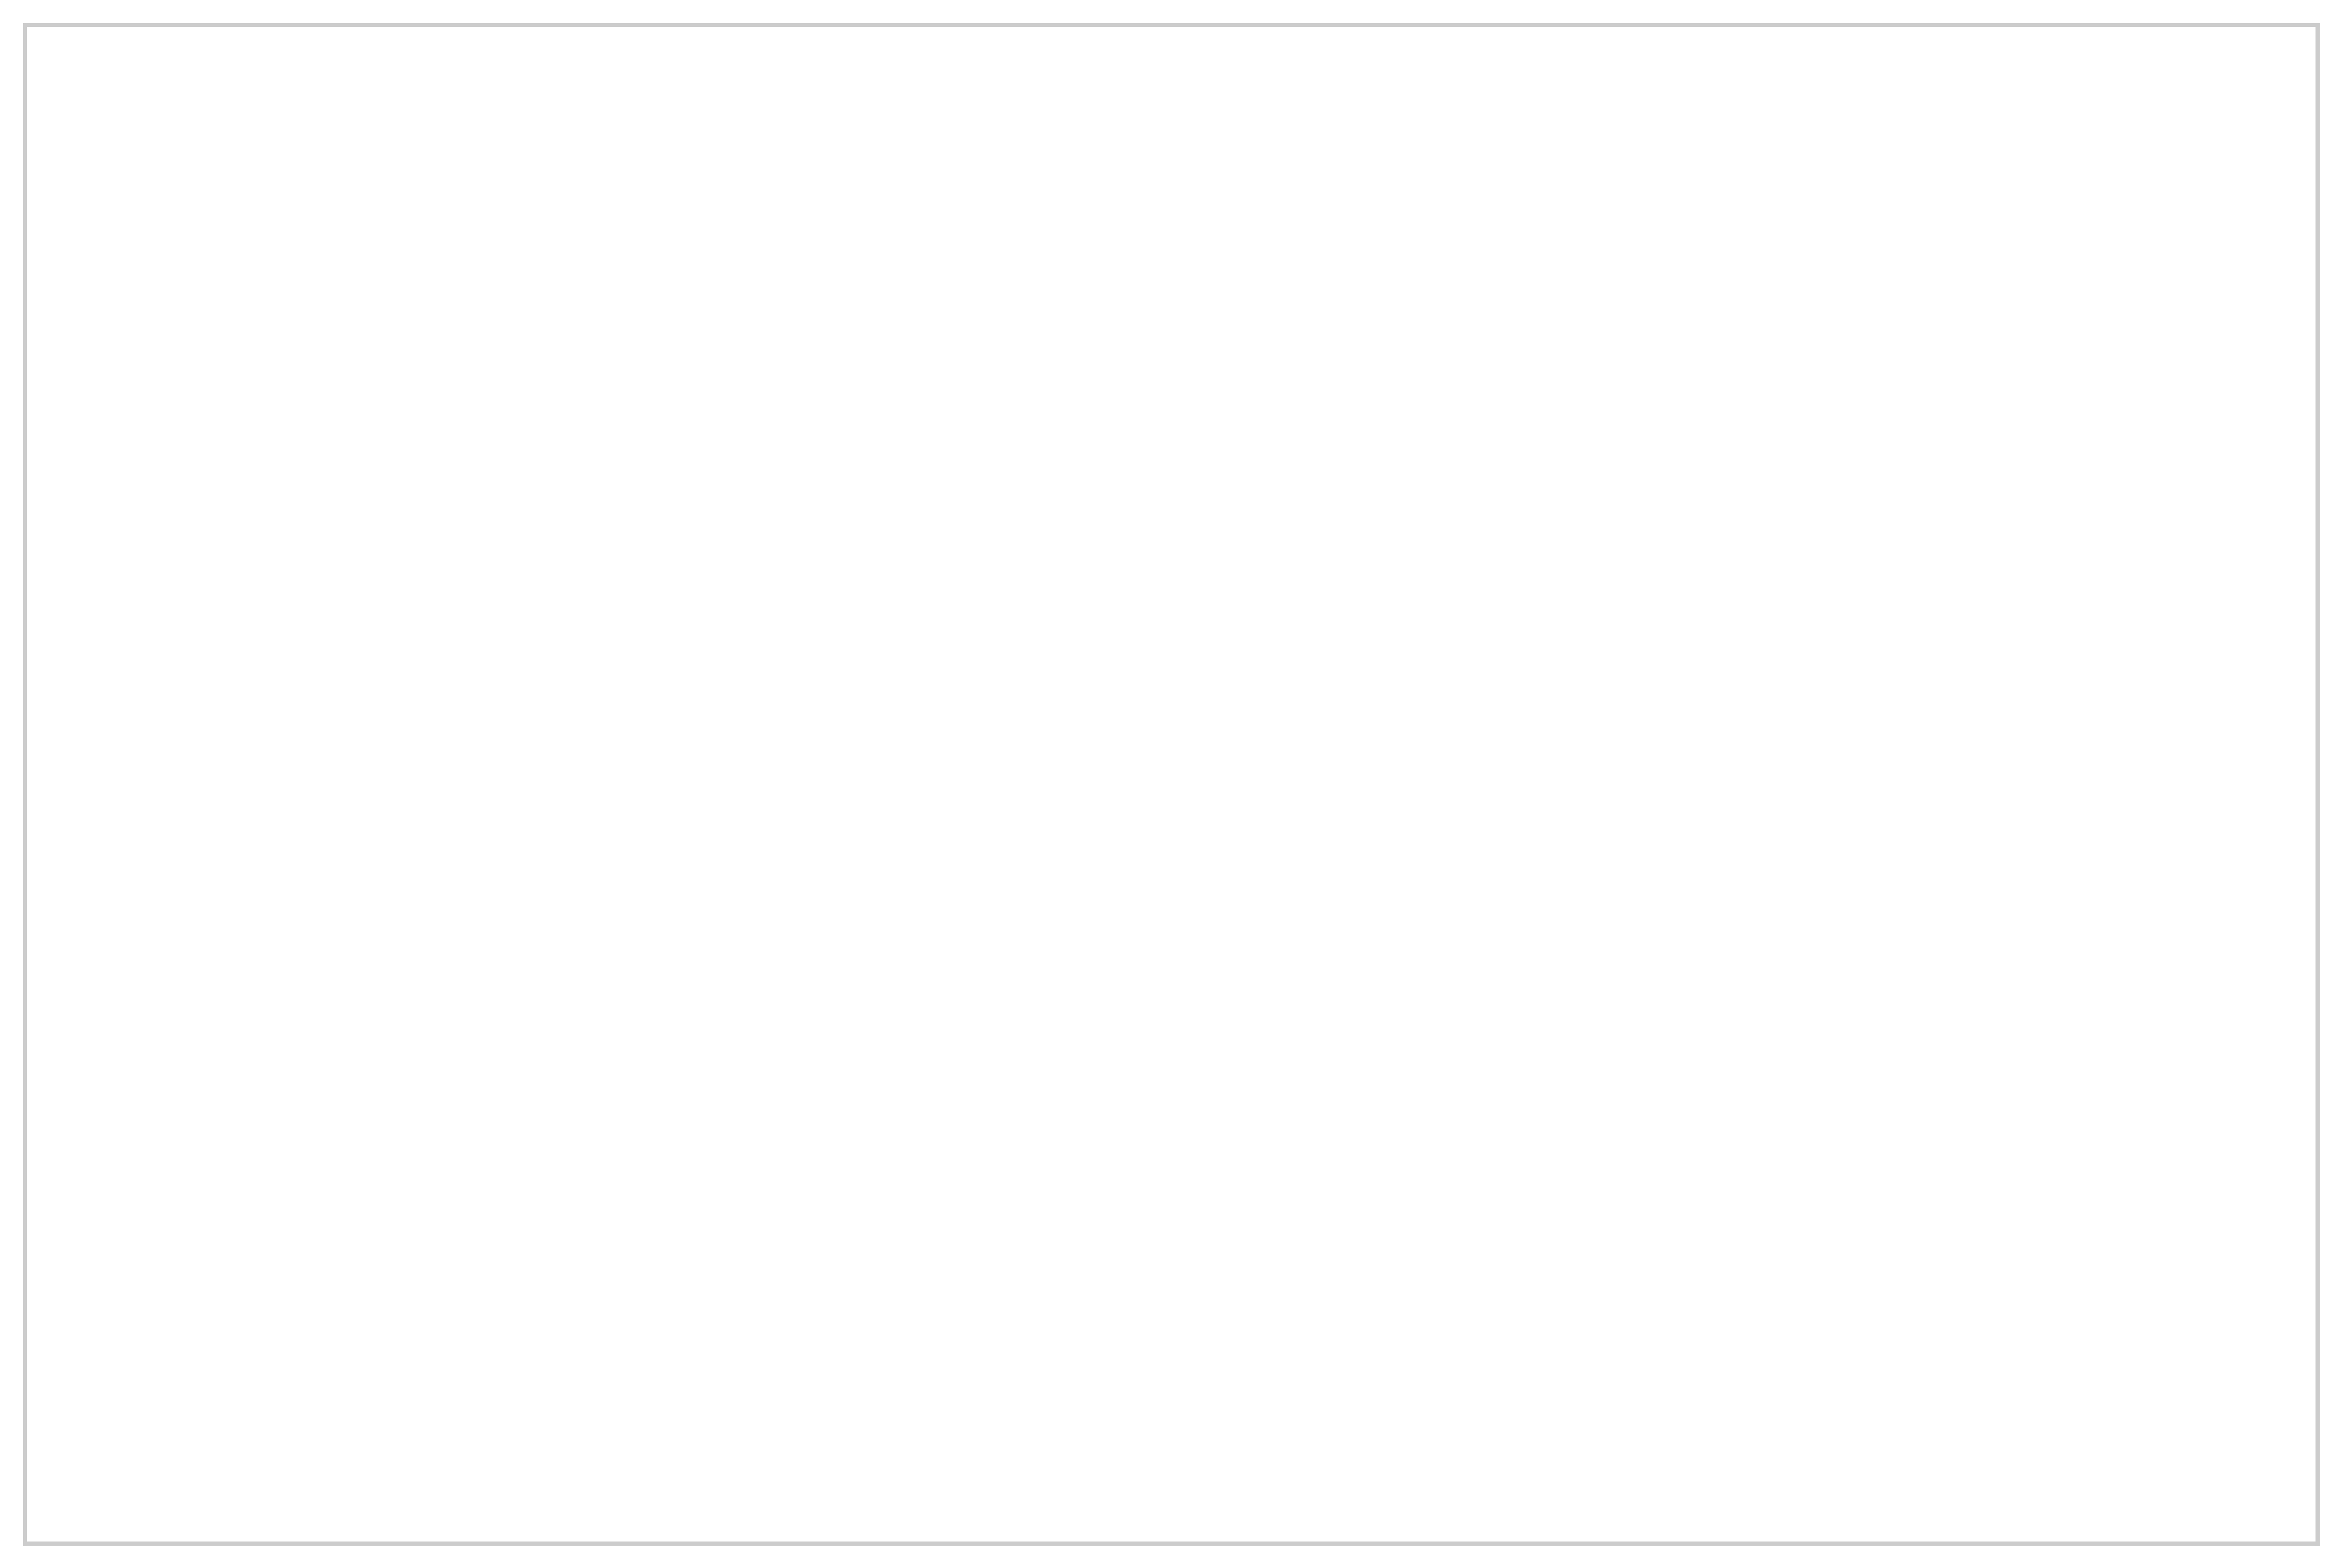

In [4]:
bacpipe.play(
    models=MODELS_LIST,       # list of models to run. Supported models are in bacpipe.supported_models
)


Top end predictions for display could not be loaded. The reason could be that a previous run failed and not all predictions were saved. Regenerating the embeddings is the best chance of getting this to work. 
'NoneType' object has no attribute 'drop'


Top end predictions for display could not be loaded. The reason could be that a previous run failed and not all predictions were saved. Regenerating the embeddings is the best chance of getting this to work. 
'NoneType' object has no attribute 'drop'


Top end predictions for display could not be loaded. The reason could be that a previous run failed and not all predictions were saved. Regenerating the embeddings is the best chance of getting this to work. 
'NoneType' object has no attribute 'drop'



Opening in existing browser session.


The port 5006 is already in use. This is most likely the case because you already have a dashboard open. There is a exit button in the bottom left of the dashboard. If this was intentional and you want to open multiple dashboards at once, ignore this message.
The port 5007 is already in use. This is most likely the case because you already have a dashboard open. There is a exit button in the bottom left of the dashboard. If this was intentional and you want to open multiple dashboards at once, ignore this message.


Launching server at http://localhost:5008


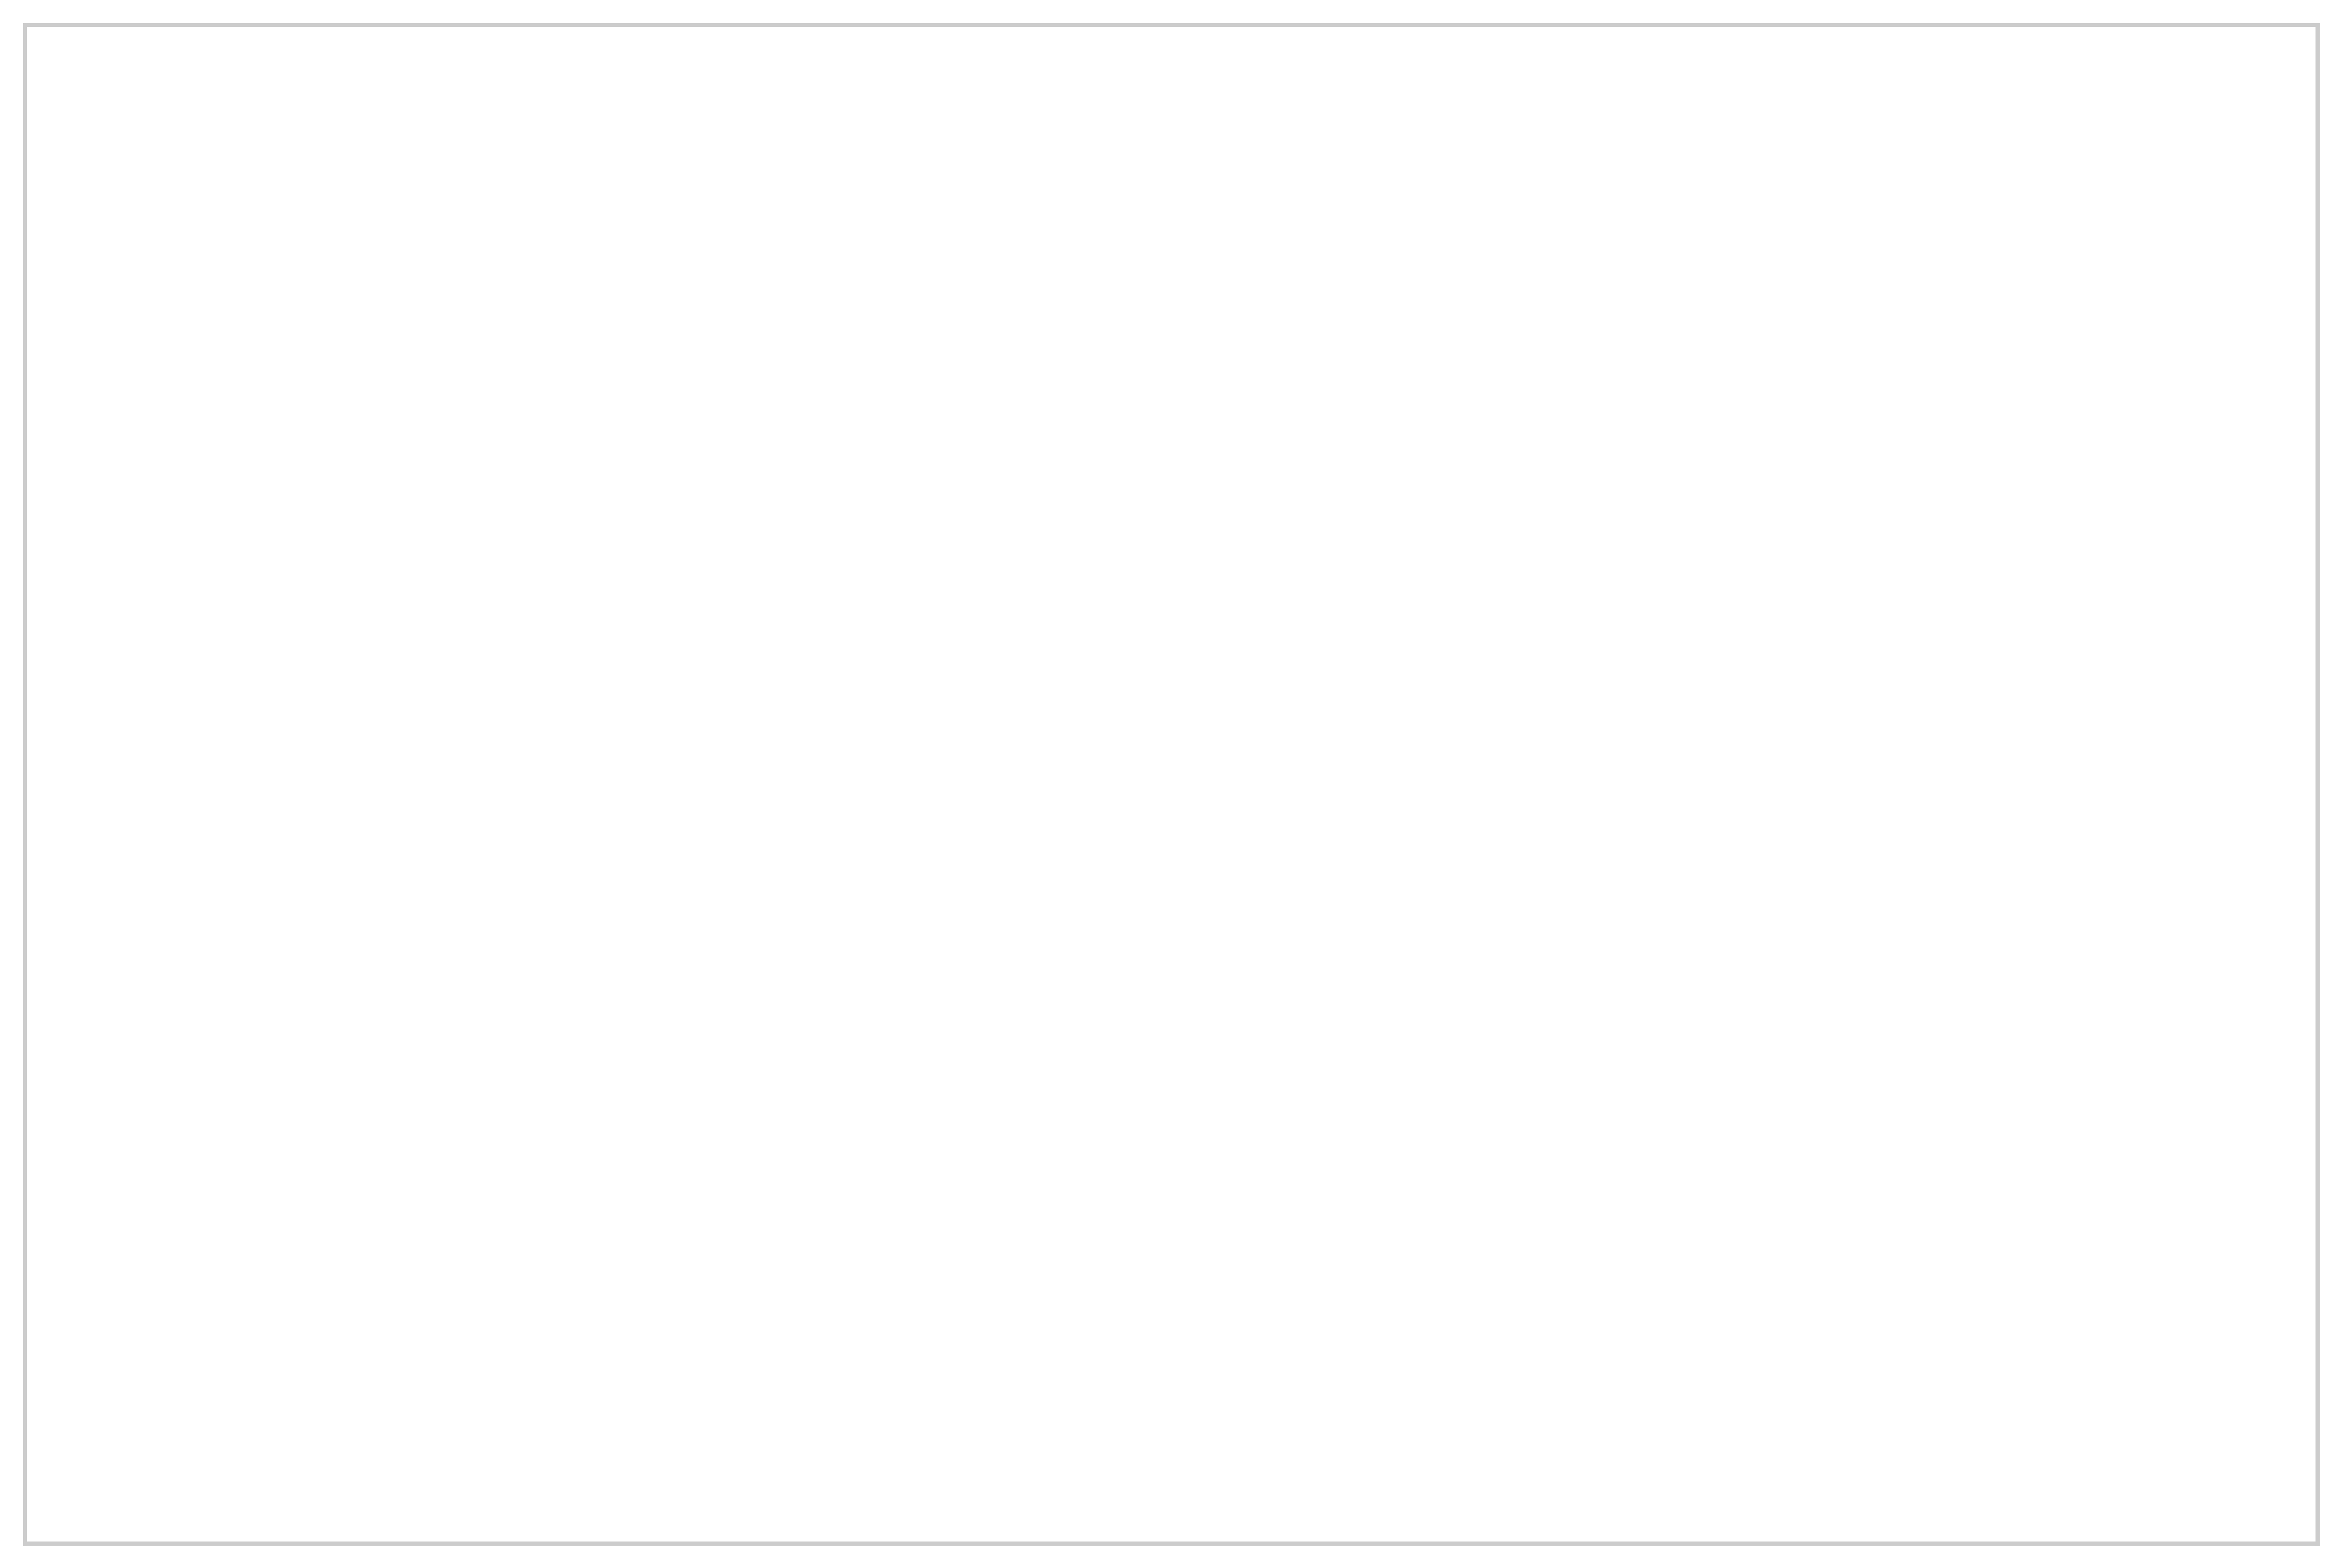

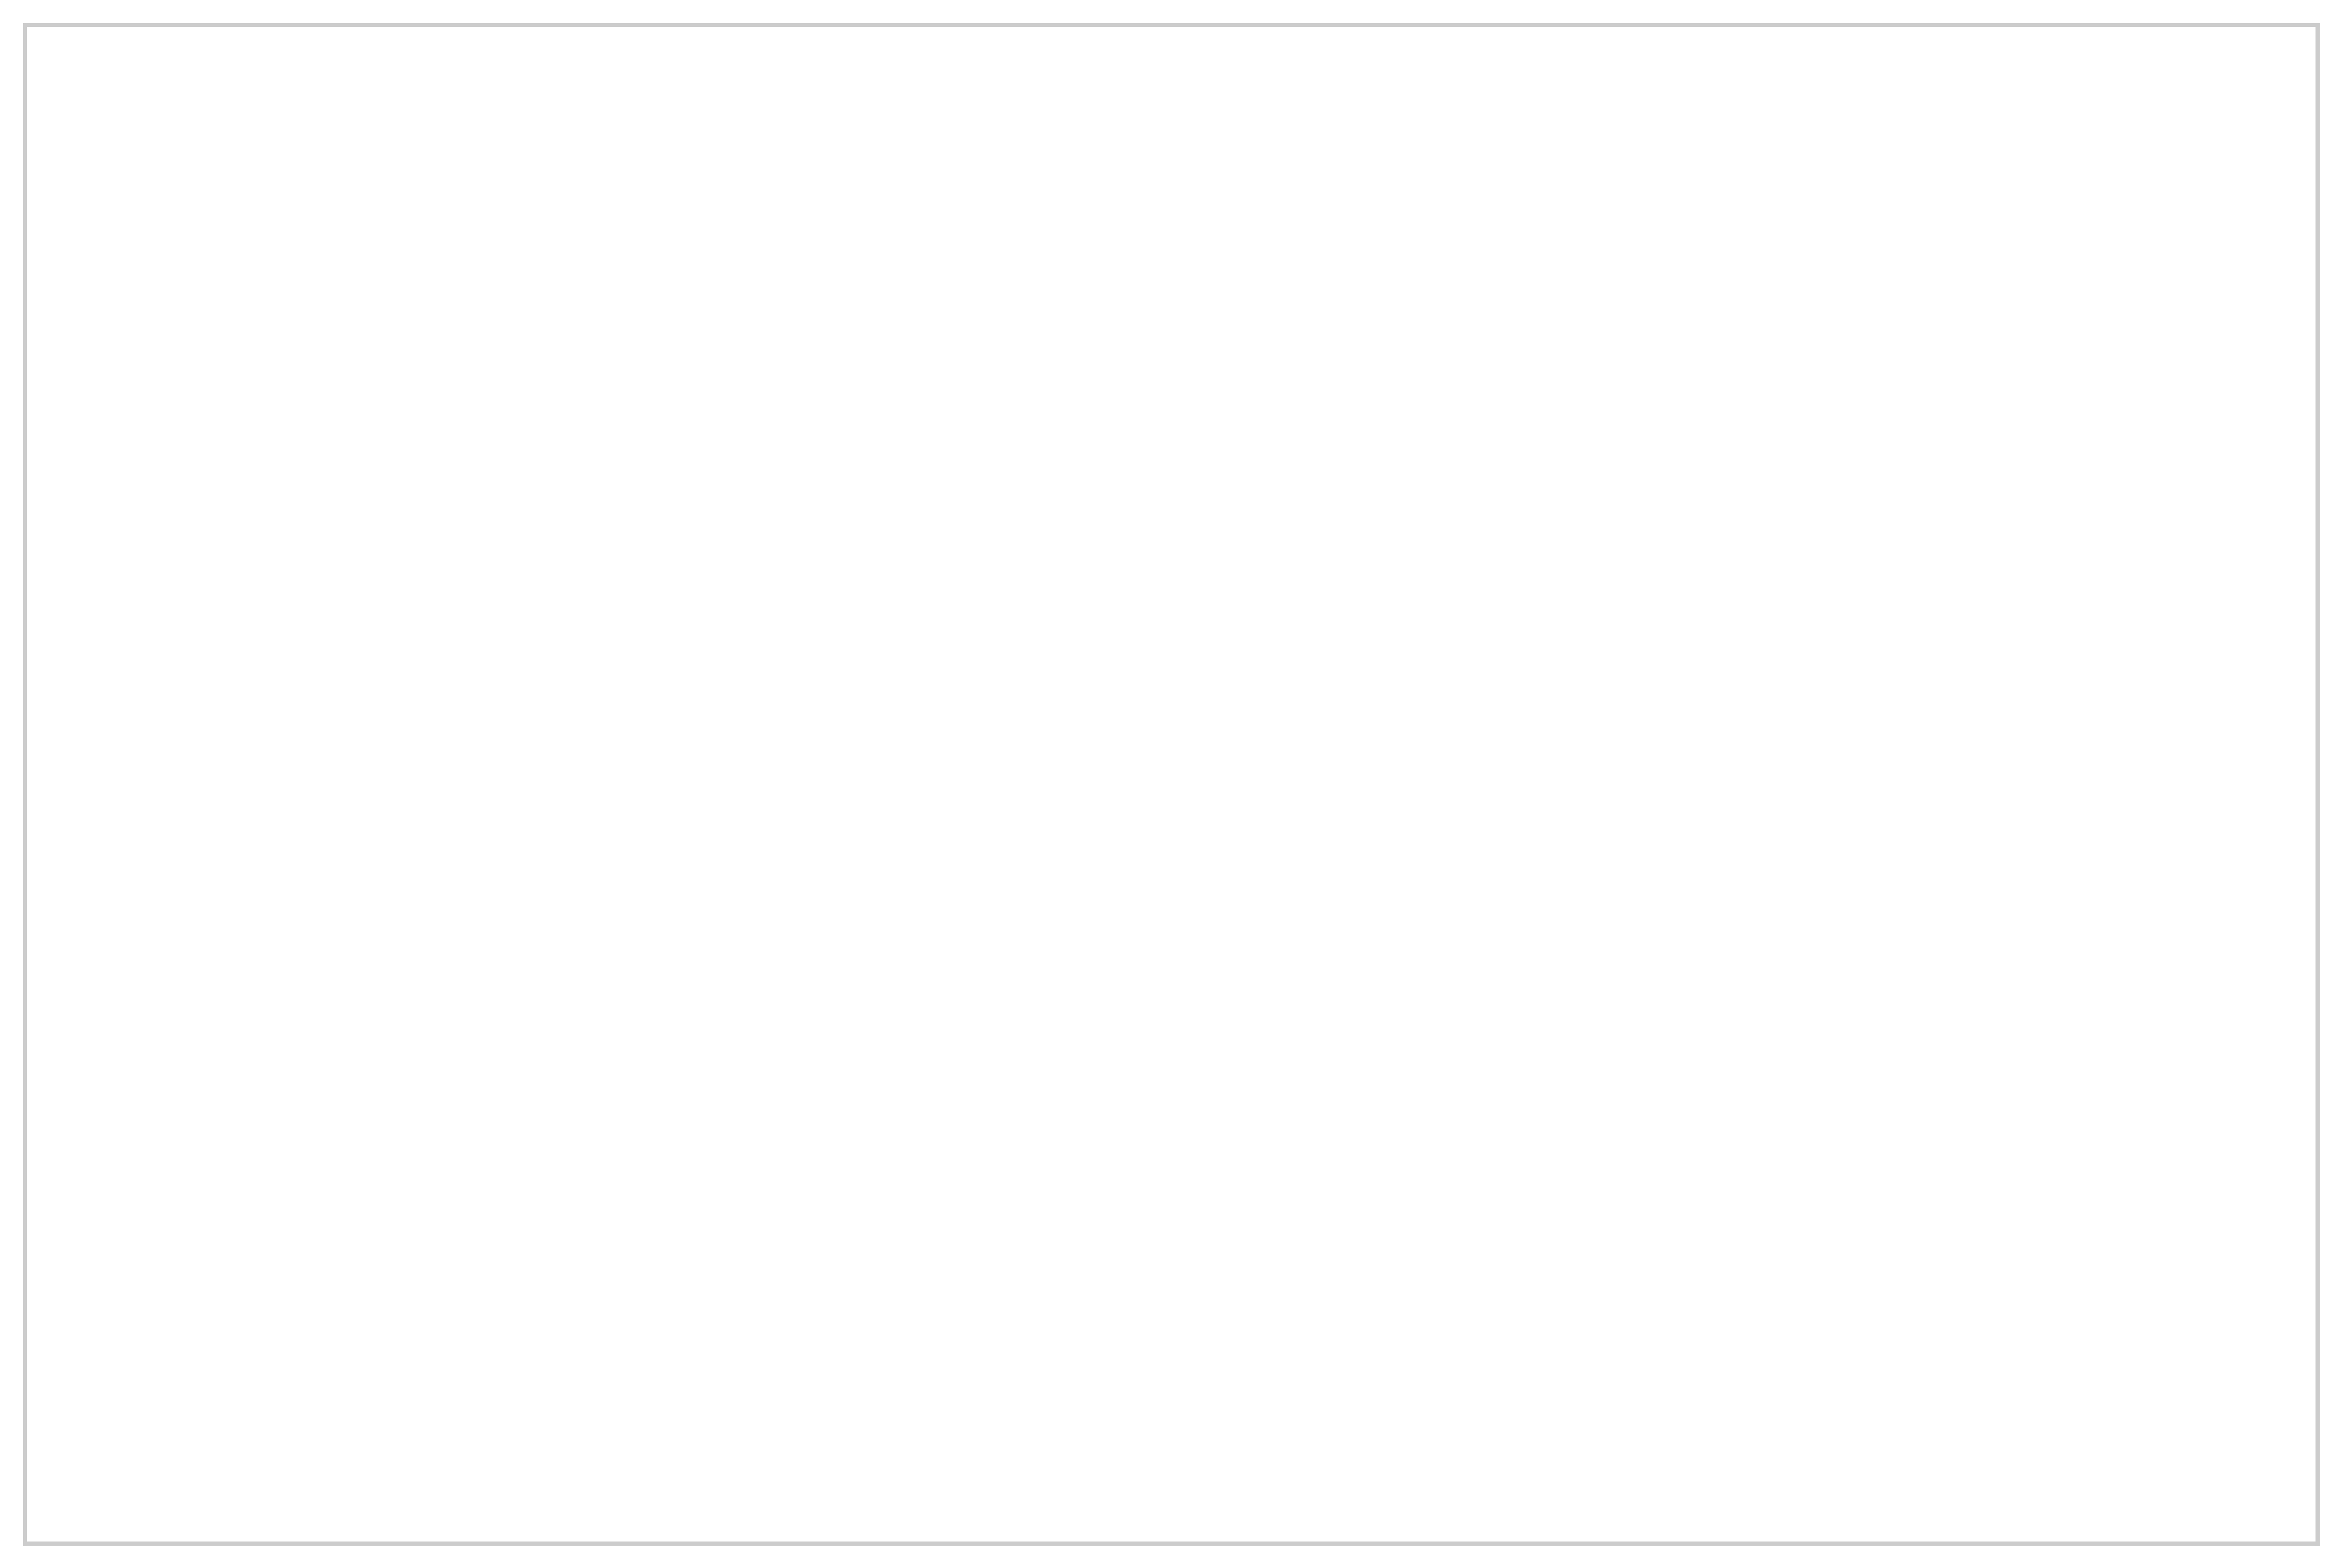

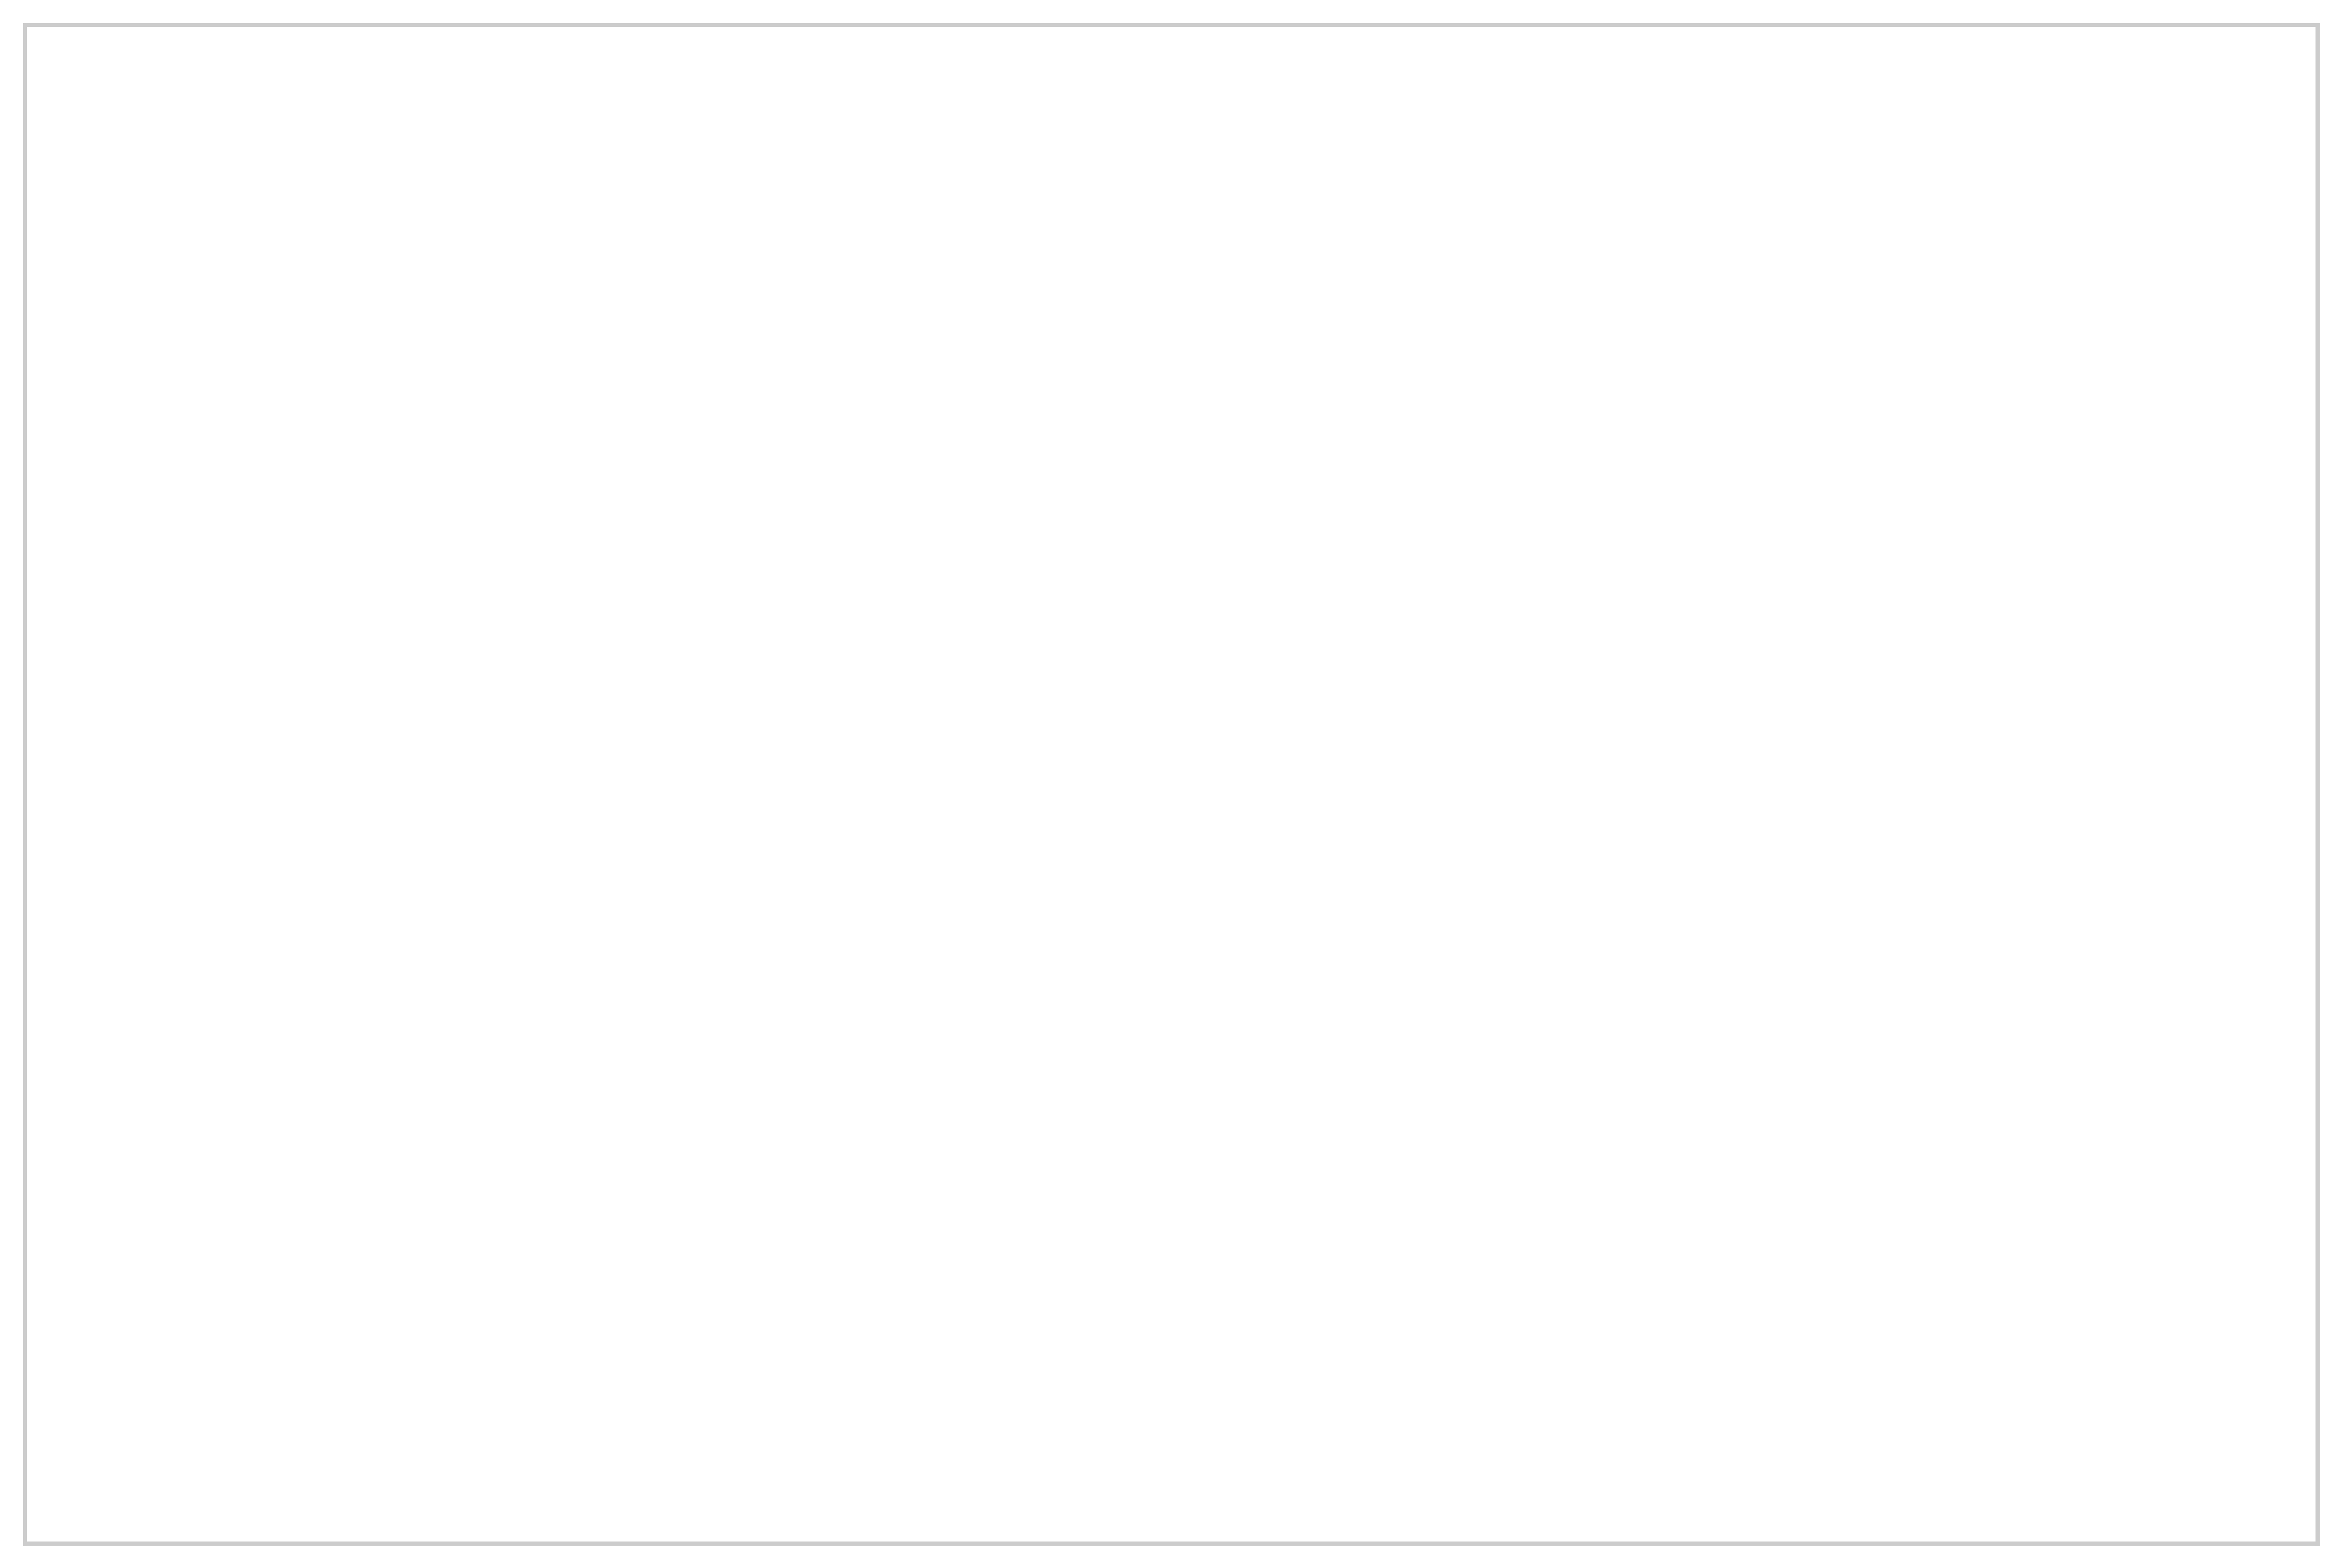

Opening in existing browser session.



Top end predictions for display could not be loaded. The reason could be that a previous run failed and not all predictions were saved. Regenerating the embeddings is the best chance of getting this to work. 
'NoneType' object has no attribute 'drop'


Top end predictions for display could not be loaded. The reason could be that a previous run failed and not all predictions were saved. Regenerating the embeddings is the best chance of getting this to work. 
'NoneType' object has no attribute 'drop'


Top end predictions for display could not be loaded. The reason could be that a previous run failed and not all predictions were saved. Regenerating the embeddings is the best chance of getting this to work. 
'NoneType' object has no attribute 'drop'


Top end predictions for display could not be loaded. The reason could be that a previous run failed and not all predictions were saved. Regenerating the embeddings is the best chance of getting this to work. 
'NoneType' object has no attrib

In [5]:
bacpipe.visualize_using_dashboard(
    models=['birdnet','birdnet_v3'],
    audio_dir=bacpipe.config.audio_dir,
    main_results_dir=bacpipe.settings.main_results_dir,
)

In [6]:
# compute the 